# How does the label itself move over time?

*Setup cells below are carried from the shared analysis so this notebook runs on its own.*


In [1]:
from pathlib import Path

import polars as pl

from fraud_detection.evaluation.time_consistency import scan, time_windows

C = [f"C{i}" for i in range(1, 15)]
D = [f"D{i}" for i in range(1, 16)]
M = [f"M{i}" for i in range(1, 10)]
V = [f"V{i}" for i in range(1, 340)]
FEATURES = C + D + M + V

# ../input on a Kaggle kernel, kaggle/raw locally (see kaggle/download.py)
CANDIDATES = [
    Path("../input/ieee-fraud-detection/train_transaction.csv"),
    Path("../../kaggle/raw/train_transaction.csv"),
    Path("../kaggle/raw/train_transaction.csv"),
    Path("kaggle/raw/train_transaction.csv"),
]
csv = next((p for p in CANDIDATES if p.exists()), None)
if csv is None:
    raise FileNotFoundError(
        "train_transaction.csv not found. On Kaggle, add the ieee-fraud-detection "
        "competition data to this notebook; locally, run `uv run python kaggle/download.py`."
    )

df = pl.read_csv(
    csv,
    columns=["TransactionDT", "isFraud"] + FEATURES,
    schema_overrides={c: pl.Float32 for c in V},
)
print(f"{len(df):,} rows, {len(FEATURES)} features")

590,540 rows, 377 features


In [2]:
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm

DAY = 86400

# Categorical slots, checked for colour-vision deficiency across every pair.
PASS, INVERTED, WEAK = "#2a78d6", "#eb6834", "#1baf7a"
VERDICT_COLOR = {"pass": PASS, "inverted": INVERTED, "weak": WEAK}
BLUE_LIGHT = "#9ec5f4"
INK, MUTED, GRID, SURFACE = "#0b0b0b", "#898781", "#e1e0d9", "#fcfcfb"

# Signed magnitude gets a diverging ramp: degradation red, improvement blue, gray at 0.
DELTA_CMAP = LinearSegmentedColormap.from_list("delta", ["#e34948", "#f0efec", PASS])

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "figure.dpi": 130, "font.size": 9, "text.color": INK,
    "axes.edgecolor": MUTED, "axes.labelcolor": INK, "axes.titlecolor": INK,
    "axes.titlesize": 10, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "legend.frameon": False,
})

In [3]:
train, holdout = time_windows(df, "TransactionDT", train=(0.0, 0.17), holdout=(0.83, 1.0))
print(f"train {len(train):,}   skipped {len(df) - len(train) - len(holdout):,}   holdout {len(holdout):,}")

train 100,392   skipped 389,755   holdout 100,393


In [5]:
scan(train, holdout, ["C3", "C7"], "isFraud").select(
    ["feature", "verdict", "auc_train", "auc_holdout", "delta"]
)

feature,verdict,auc_train,auc_holdout,delta
str,str,f64,f64,f64
"""C3""","""weak""",0.5055,0.502,-0.0035
"""C7""","""pass""",0.6499,0.6638,0.0139


In [6]:
block = scan(train, holdout, [f"V{i}" for i in range(322, 340)], "isFraud")
print(block["verdict"].value_counts().sort("count", descending=True), "\n")
block.select(["feature", "verdict", "auc_train", "auc_holdout", "delta"])

shape: (2, 2)
┌──────────┬───────┐
│ verdict  ┆ count │
│ ---      ┆ ---   │
│ str      ┆ u32   │
╞══════════╪═══════╡
│ inverted ┆ 12    │
│ pass     ┆ 6     │
└──────────┴───────┘ 



feature,verdict,auc_train,auc_holdout,delta
str,str,f64,f64,f64
"""V334""","""inverted""",0.5672,0.4644,-0.1028
"""V335""","""inverted""",0.5709,0.4691,-0.1017
"""V336""","""inverted""",0.5698,0.4709,-0.0989
"""V325""","""inverted""",0.5613,0.464,-0.0972
"""V337""","""inverted""",0.5675,0.473,-0.0946
…,…,…,…,…
"""V333""","""pass""",0.5834,0.493,-0.0905
"""V332""","""pass""",0.5833,0.4974,-0.0859
"""V322""","""pass""",0.5669,0.49,-0.0769


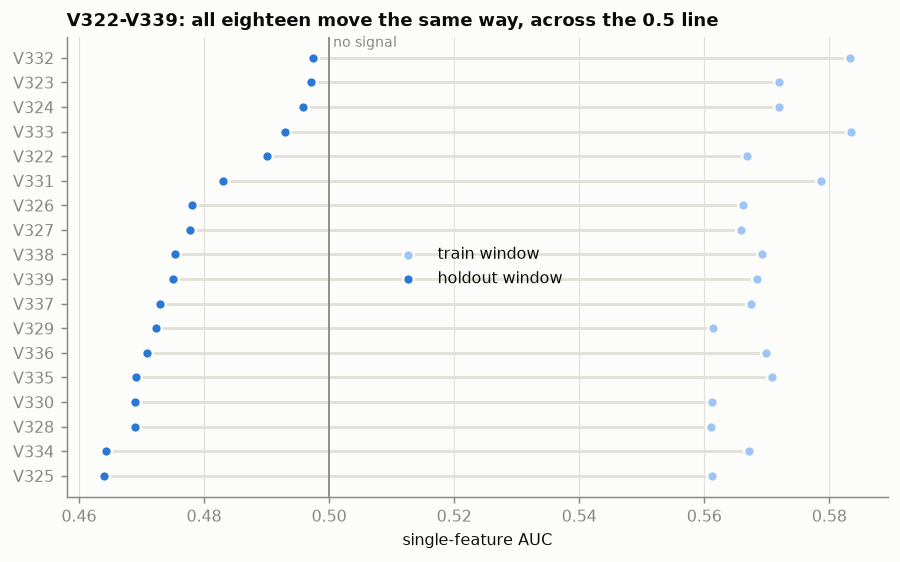

In [7]:
b = block.sort("auc_holdout")
y = range(len(b))

fig, ax = plt.subplots(figsize=(7, 4.4))
ax.axvline(0.5, color=MUTED, lw=1)
ax.hlines(y, b["auc_train"], b["auc_holdout"], color=GRID, lw=1.6, zorder=1)
ax.scatter(b["auc_train"], y, s=36, color=BLUE_LIGHT, zorder=2,
           edgecolor=SURFACE, linewidth=1.4, label="train window")
ax.scatter(b["auc_holdout"], y, s=36, color=PASS, zorder=3,
           edgecolor=SURFACE, linewidth=1.4, label="holdout window")

ax.set_yticks(list(y), b["feature"].to_list())
ax.set_xlabel("single-feature AUC")
ax.set_title("V322-V339: all eighteen move the same way, across the 0.5 line")
ax.text(0.5, len(b) - 0.4, " no signal", color=MUTED, va="center", fontsize=8)
ax.grid(axis="y", visible=False)
ax.legend(loc="center")  # the band between the two clusters is the only empty space
fig.tight_layout()

In [ ]:
report = scan(train, holdout, FEATURES, "isFraud", n_jobs=-1)
report.write_csv("time_consistency_report.csv")
report["verdict"].value_counts().sort("count", descending=True)

In [ ]:
inverted = report.filter(pl.col("verdict") == "inverted")
non_v = [f for f in inverted["feature"].to_list() if not f.startswith("V")]
print("non-V columns inverted:", non_v or "none")
inverted.select(["feature", "auc_train", "auc_holdout", "delta", "null_rate_train"]).head(15)

non-V columns inverted: none


feature,auc_train,auc_holdout,delta,null_rate_train
str,f64,f64,f64,f64
"""V160""",0.5885,0.4745,-0.114,0.6833
"""V161""",0.5794,0.4658,-0.1135,0.6833
"""V163""",0.5789,0.4661,-0.1129,0.6833
"""V159""",0.5749,0.4627,-0.1122,0.6833
"""V162""",0.579,0.4694,-0.1096,0.6833
…,…,…,…,…
"""V138""",0.5687,0.4703,-0.0984,0.6833
"""V325""",0.5613,0.464,-0.0972,0.682
"""V338""",0.5698,0.4755,-0.0943,0.682


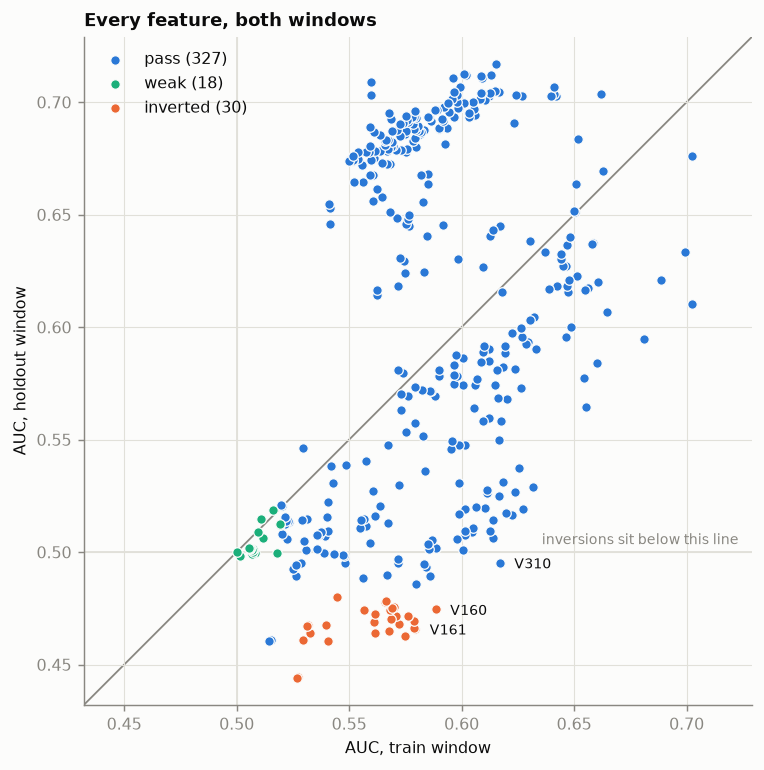

In [ ]:
ev = report.drop_nulls(subset=["auc_train", "auc_holdout"])
lo = min(ev["auc_train"].min(), ev["auc_holdout"].min()) - 0.012
hi = max(ev["auc_train"].max(), ev["auc_holdout"].max()) + 0.012

fig, ax = plt.subplots(figsize=(6.2, 6))
ax.axhline(0.5, color=GRID, lw=1, zorder=0)
ax.axvline(0.5, color=GRID, lw=1, zorder=0)
ax.plot([lo, hi], [lo, hi], color=MUTED, lw=1, zorder=1)

for verdict in ("pass", "weak", "inverted"):
    s = ev.filter(pl.col("verdict") == verdict)
    ax.scatter(s["auc_train"], s["auc_holdout"], s=28, color=VERDICT_COLOR[verdict],
               edgecolor=SURFACE, linewidth=0.7, zorder=3, label=f"{verdict} ({len(s)})")

for r in ev.sort("delta").head(3).iter_rows(named=True):
    ax.annotate(r["feature"], (r["auc_train"], r["auc_holdout"]), textcoords="offset points",
                xytext=(8, -3), fontsize=8, color=INK)

ax.set_xlim(lo, hi)
ax.set_ylim(lo, hi)
ax.set_aspect("equal")
ax.set_xlabel("AUC, train window")
ax.set_ylabel("AUC, holdout window")
ax.set_title("Every feature, both windows")
ax.text(hi - 0.004, 0.502, "inversions sit below this line ", ha="right", va="bottom",
        fontsize=8, color=MUTED)
ax.legend(loc="upper left")
fig.tight_layout()

In [ ]:
BLOCKS = {
    "V1-V11": (1, 11), "V12-V34": (12, 34), "V35-V52": (35, 52), "V53-V74": (53, 74),
    "V75-V94": (75, 94), "V95-V137": (95, 137), "V138-V166": (138, 166),
    "V167-V216": (167, 216), "V217-V278": (217, 278), "V279-V321": (279, 321),
    "V322-V339": (322, 339),
}

idx = lambda f: int(f[1:])
inv = set(inverted["feature"].to_list())


def block_null_rate(lo: int, hi: int) -> float:
    """Mean null share across the block's columns."""
    cols = [f"V{i}" for i in range(lo, hi + 1)]
    shares = df.select(pl.col(cols).null_count() / len(df)).row(0)
    return round(sum(shares) / len(shares), 3)


blocks = pl.DataFrame(
    [
        {
            "block": name,
            "inverted": sum(1 for f in inv if lo <= idx(f) <= hi),
            "n_columns": hi - lo + 1,
            "null_rate": block_null_rate(lo, hi),
        }
        for name, (lo, hi) in BLOCKS.items()
    ]
)
blocks.sort("inverted", descending=True)

block,inverted,n_columns,null_rate
str,i64,i64,f64
"""V322-V339""",12,18,0.861
"""V138-V166""",8,29,0.861
"""V53-V74""",6,22,0.131
"""V12-V34""",2,23,0.129
"""V75-V94""",2,20,0.151
…,…,…,…
"""V35-V52""",0,18,0.286
"""V95-V137""",0,43,0.001
"""V167-V216""",0,50,0.763


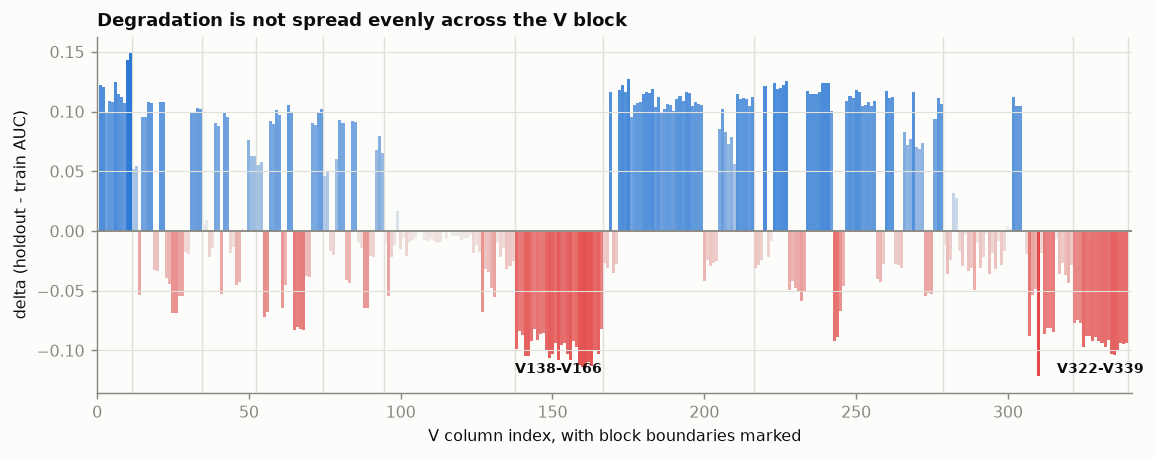

In [ ]:
v = (
    report.filter(pl.col("feature").str.contains(r"^V\d+$"))
    .drop_nulls(subset=["delta"])
    .with_columns(pl.col("feature").str.slice(1).cast(pl.Int32).alias("idx"))
    .sort("idx")
)
v_idx, v_delta = v["idx"].to_numpy(), v["delta"].to_numpy()
norm = TwoSlopeNorm(vmin=v_delta.min(), vcenter=0.0, vmax=v_delta.max())

fig, ax = plt.subplots(figsize=(9, 3.6))
ax.bar(v_idx, v_delta, width=1.0, color=DELTA_CMAP(norm(v_delta)))
ax.axhline(0, color=MUTED, lw=1)

for lo_i, hi_i in BLOCKS.values():
    ax.axvline(hi_i + 0.5, color=GRID, lw=0.8, zorder=0)
for name in ("V138-V166", "V322-V339"):
    lo_i, hi_i = BLOCKS[name]
    ax.annotate(name, ((lo_i + hi_i) / 2, v_delta.min()), ha="center", va="bottom",
                fontsize=8, fontweight="bold", color=INK)

ax.set_xlim(0, 341)
ax.set_xlabel("V column index, with block boundaries marked")
ax.set_ylabel("delta (holdout - train AUC)")
ax.set_title("Degradation is not spread evenly across the V block")
ax.grid(axis="x", visible=False)
fig.tight_layout()

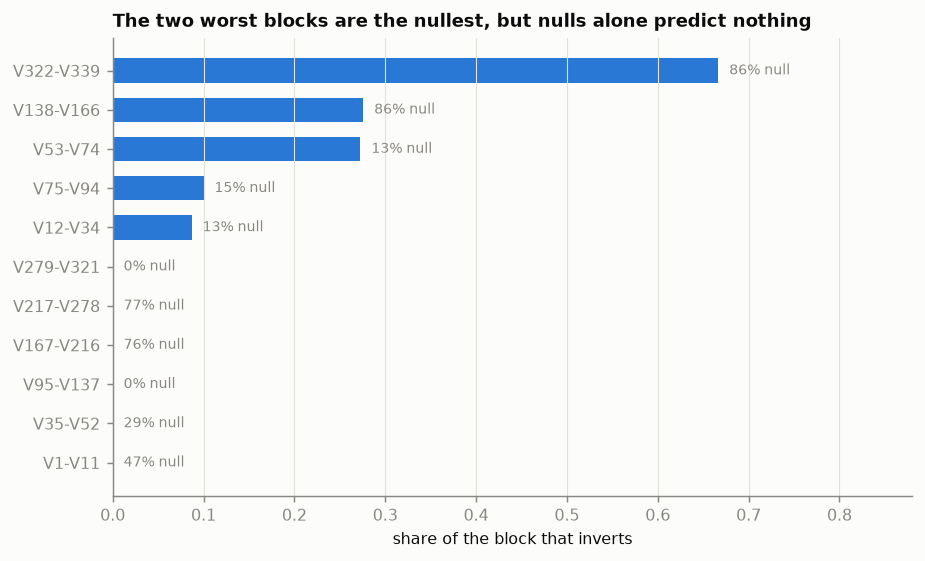

In [ ]:
by_share = blocks.with_columns(
    (pl.col("inverted") / pl.col("n_columns")).alias("share")
).sort("share")

fig, ax = plt.subplots(figsize=(7, 4.2), layout="constrained")
ax.barh(by_share["block"].to_list(), by_share["share"].to_numpy(), color=PASS, height=0.62)

for y, r in enumerate(by_share.iter_rows(named=True)):
    ax.text(r["share"] + 0.012, y, f"{r['null_rate']:.0%} null", va="center",
            fontsize=8, color=MUTED)

ax.set_xlim(0, 0.88)
ax.set_xlabel("share of the block that inverts")
ax.set_title("The two worst blocks are the nullest, but nulls alone predict nothing")
ax.grid(axis="y", visible=False)

In [ ]:
def span_days(d: pl.DataFrame) -> float:
    return (d["TransactionDT"].max() - d["TransactionDT"].min()) / DAY


rows = []
for frac in (0.10, 0.17, 0.25):
    tr, ho = time_windows(df, "TransactionDT", train=(0.0, frac), holdout=(1 - frac, 1.0))
    rows.append({
        "fraction": frac,
        "train_rows": len(tr), "train_days": round(span_days(tr), 1),
        "train_fraud": round(tr["isFraud"].mean(), 4),
        "holdout_rows": len(ho), "holdout_days": round(span_days(ho), 1),
        "holdout_fraud": round(ho["isFraud"].mean(), 4),
        "gap_days": round((ho["TransactionDT"].min() - tr["TransactionDT"].max()) / DAY, 1),
    })

pl.DataFrame(rows)

fraction,train_rows,train_days,train_fraud,holdout_rows,holdout_days,holdout_fraud,gap_days
f64,i64,f64,f64,i64,f64,f64,f64
0.1,59054,14.8,0.0276,59055,21.1,0.0375,146.2
0.17,100392,22.6,0.0256,100393,35.1,0.0343,124.3
0.25,147635,34.0,0.0263,147636,52.8,0.0345,95.1


In [ ]:
inv = report.filter(pl.col("verdict") == "inverted")["feature"].to_list()
ctrl = report.filter(pl.col("verdict") == "pass")["feature"].sample(25, seed=0).to_list()


def by_feature(frame: pl.DataFrame, column: str) -> dict:
    """`{feature: value}` -- polars has no index, and a dict is what the lookups below want."""
    return dict(zip(frame["feature"].to_list(), frame[column].to_list()))


sens = {}
for frac in (0.10, 0.25):
    tr, ho = time_windows(df, "TransactionDT", train=(0.0, frac), holdout=(1 - frac, 1.0))
    rep = scan(tr, ho, inv + ctrl, "isFraud", n_jobs=-1)
    sens[frac] = rep
    verdicts = by_feature(rep, "verdict")
    still_inverted = sum(verdicts[f] == "inverted" for f in inv) / len(inv)
    still_pass = sum(verdicts[f] == "pass" for f in ctrl) / len(ctrl)
    print(f"frac={frac:.2f}   of {len(inv)} inverted, still inverted: {still_inverted:.0%}"
          f"   |   of {len(ctrl)} pass controls, still pass: {still_pass:.0%}")

base_delta = by_feature(report, "delta")
for frac in (0.10, 0.25):
    d = by_feature(sens[frac], "delta")
    pairs = pl.DataFrame({"then": [d[f] for f in inv], "base": [base_delta[f] for f in inv]})
    corr = pairs.select(pl.corr("then", "base")).item()
    print(f"delta correlation, {frac:.2f} vs 0.17: {corr:.3f}")

frac=0.10   of 30 inverted, still inverted: 40%   |   of 25 pass controls, still pass: 100%


frac=0.25   of 30 inverted, still inverted: 87%   |   of 25 pass controls, still pass: 96%
delta correlation, 0.10 vs 0.17: 0.870
delta correlation, 0.25 vs 0.17: 0.930


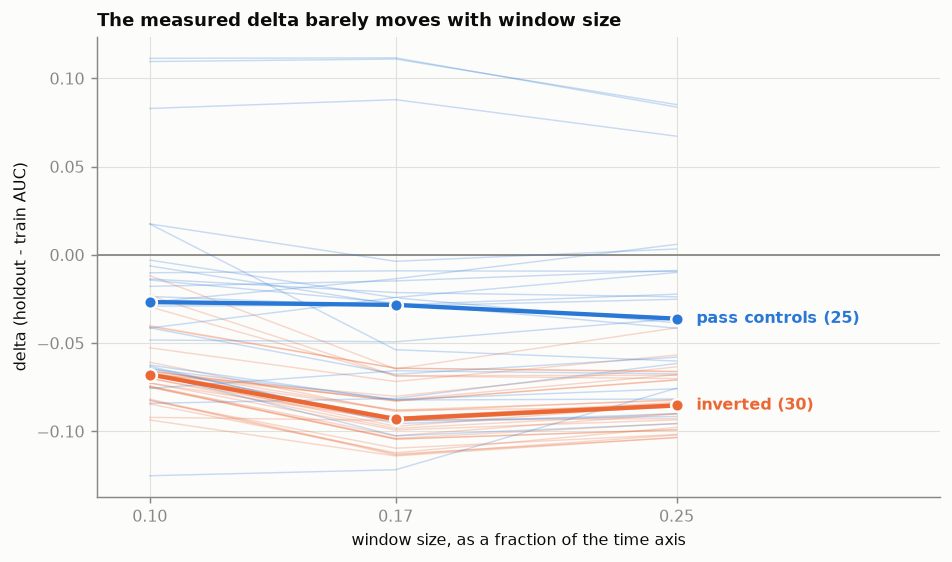

In [ ]:
fracs = [0.10, 0.17, 0.25]
curves = {"inverted": (inv, INVERTED), "pass controls": (ctrl, PASS)}
delta_at = {f: by_feature(sens[f], "delta") for f in (0.10, 0.25)} | {0.17: base_delta}

fig, ax = plt.subplots(figsize=(7.4, 4.4))
ax.axhline(0, color=MUTED, lw=1)

for label, (feats, color) in curves.items():
    series = [[delta_at[f][feature] for f in fracs] for feature in feats]
    for row in series:
        ax.plot(fracs, row, color=color, lw=0.8, alpha=0.25, zorder=2)
    median = [pl.Series([r[i] for r in series]).median() for i in range(3)]
    ax.plot(fracs, median, color=color, lw=2.4, marker="o", ms=7, zorder=4,
            markeredgecolor=SURFACE, markeredgewidth=1.4)
    # Direct labels at the right endpoint: a legend box has nowhere to sit here.
    ax.annotate(f"{label} ({len(feats)})", (fracs[-1], median[-1]),
                textcoords="offset points", xytext=(11, 0), va="center",
                fontsize=9, fontweight="bold", color=color)

ax.set_xlim(0.085, 0.325)
ax.set_xticks(fracs, [f"{f:.2f}" for f in fracs])
ax.set_xlabel("window size, as a fraction of the time axis")
ax.set_ylabel("delta (holdout - train AUC)")
ax.set_title("The measured delta barely moves with window size")
fig.tight_layout()

## Pipeline Integration

Output: Pinned list of allowed columns. Run only when data changes.

# Appendix — summary of this analysis

> The same write-up ships as the README of the extracted standalone library,
> [`ieee-cis-fraud-detection-time-consistency`](https://github.com/jjabuk/ieee-cis-fraud-detection-time-consistency).
> The numbers below are this notebook's own run.

**Which features in the IEEE-CIS fraud dataset stop meaning the same thing over time?**

Train a model on a *single* feature using an early slice of the data, then score a later
slice. A feature that ranks one way in the past and the opposite way in the future found a
pattern that does not survive the time axis. A random-split validation will never tell
you, because it lets the model see the same period it is scored on.

The check is described in the competition's
[1st Place Solution — Part 2](https://www.kaggle.com/competitions/ieee-fraud-detection/writeups/fraudsquad-1st-place-solution-part-2)
writeup, along with three concrete results. This repository implements it, reproduces
those three, and runs the same sweep over the rest of the dataset.

```python
from time_consistency import scan, time_windows

train, holdout = time_windows(df, "TransactionDT", train=(0.0, 0.17), holdout=(0.83, 1.0))
report = scan(train, holdout, features, label="isFraud")
```

```
feature   verdict  auc_train  auc_holdout   delta
   V160  inverted     0.5885       0.4745 -0.1140
   V161  inverted     0.5794       0.4658 -0.1135
     C7      pass     0.6508       0.6637  0.0129
     C3      weak     0.5055       0.5020 -0.0035
```

Worst first. `inverted` is the one that matters.

## The three results in the writeup

| From the writeup | Stated | Measured here |
| --- | --- | --- |
| `C3`, no signal either way | ≈ 0.5 / 0.5 | **0.5055 / 0.5020** |
| `C7`, signal that holds | ≈ 0.65 / 0.67 | **0.6508 / 0.6637** |
| `V322–V339`, the block fails the check | removed from their models | **all 18 columns degrade**, 12 cross the inversion threshold |

The two AUC pairs land within a thousandth, on window bounds derived independently.

## What the sweep says about the rest

377 columns (`C1–C14`, `D1–D15`, `M1–M9`, `V1–V339`) on `train_transaction.csv`, the first
17% of the time axis against the last 17%. The other fourteen transaction features
(`TransactionAmt`, `ProductCD`, `card1–6`, `addr1–2`, `dist1–2`, the two email domains) and
the `id_*` columns are out of scope.

| Verdict | Columns |
| --- | ---: |
| `pass` | 327 |
| `inverted` | **30** |
| `weak` | 18 |
| `degenerate` | 2 |

Every inversion is a V column. Not one `C`, `D` or `M` column inverts, and within the V
block the failures cluster:

| V range | Inverted | Of | Null rate |
| --- | ---: | ---: | ---: |
| V322–V339 | **12** | 18 | 86% |
| V138–V166 | **8** | 29 | 86% |
| V53–V74 | 6 | 22 | 13% |
| V12–V34 | 2 | 23 | 13% |
| V75–V94 | 2 | 20 | 15% |
| six other ranges | 0 | 227 | — |

Two blocks hold two thirds of the problem, and both sit around 86% null. Missingness on
its own does not order the blocks: `V167–V216` and `V217–V278` are 76% and 77% null and
produce no inversions at all, while `V53–V74` is 13% null and produces six.

### Read the delta, not the verdict

`V310` has the largest degradation in the dataset, a delta of **−0.1218**, worse than any
column the check rejects. Its holdout AUC of 0.4952 misses the inversion margin by three
thousandths, so it comes back `pass`. Twenty-two `pass` columns degrade by more than −0.09.

`V322–V339` says the same thing from the other side: every column in the block moves by
−0.09 ± 0.015, and the split into twelve rejected and six passed follows from where the
threshold sits rather than from anything in the data. Those eighteen columns share
contiguous indices and one missingness pattern, so group columns by NaN structure first,
then judge the group by its delta.

## Run it

From this repository:

```bash
uv sync
uv run python kaggle/download.py        # → kaggle/raw/, gitignored
uv run jupyter lab eda/notebooks/06-time-consistency.ipynb
```

`kaggle/download.py` pulls the competition CSVs through `kagglehub`. You need a Kaggle
account that has accepted the competition rules, with credentials in `~/.kaggle/kaggle.json`
or in `KAGGLE_USERNAME` / `KAGGLE_KEY`.

The notebook imports `fraud_detection.evaluation.time_consistency` — the same module
`assets/feature_audit.py` calls, so the notebook and the pipeline compute one thing rather
than two. It also runs unchanged as a Kaggle kernel, where the fallback installs the
extracted package instead.

The same file runs as a Kaggle kernel. Add the competition data to the notebook and switch
**Internet** on in its settings, so the first cell can install this package from GitHub when
the import fails. Without internet, attach the repository as a utility script instead.

## Verdicts

| Verdict | Meaning |
| --- | --- |
| `pass` | Signal survives the time axis. |
| `inverted` | Clears the margin above 0.5 in training and below 0.5 in the holdout. |
| `weak` | No signal on its own in either window. Harmless, but not evidence. |
| `degenerate` | Not evaluable: constant, all-null, or a window without both classes. |

A tree trained on a single feature learns a direction, so a holdout AUC below 0.5 means
that direction reversed. `M1` and `V107` come back `degenerate` here, both constant inside
the training window, which is a measurement that never happened rather than a column
without signal.

One fit per feature costs about 2 s: 500 trees, 8 leaves, one column. The full sweep took
**863 s single-threaded and 271 s on eight cores** with `scan(..., n_jobs=-1)`, and every
fit is separately seeded, so the parallel output is identical to the sequential one. At
that price the check is an audit that produces a pinned list of allowed columns, re-run
when the data changes.

## Source

> Konstantin Yakovlev, Chris Deotte. *1st Place Solution — Part 2*. Kaggle, 2019.
> <https://www.kaggle.com/competitions/ieee-fraud-detection/writeups/fraudsquad-1st-place-solution-part-2>

The implementation, the guards, the verdict taxonomy and the block-level reading are this
repository's own. The competition data is not redistributed here; fetch it from Kaggle
under the competition's own terms.

[MIT](../../LICENSE).
